<h1 style="color:#004080; font-size:2em; margin-bottom:0.3em;">
  S3 Write: Comparing NOAA AORC vs. USGS CONUS404 Across Headwater Watersheds
</h1>
<h4 style="color:gray; font-weight:normal; line-height:1.5;">
  This use case explores how two high-resolution meteorological forcing datasets: the USGS/NCAR CONUS404 reanalysis (~80&nbsp;TB) and NOAA's Analysis of Record for Calibration (AORC, ~27&nbsp;TB). By examining their precipitation outputs over several diverse headwater watersheds, we aim to assess the consistency between these data sources and understand the differences in forcing data that could lead to different streamflow predictions. Also determining whether the pattern of differences is consistent across regions, so guiding researchers on how to deal with multi-source meteorological data in modeling scenarios.
</h4>





<div style="background-color: #f7f7f7; padding: 10px; border-radius: 5px;">
    <p><strong>Authors:</strong> 
    <ul>
        <li>Irene Garousi-Nejad, <a href="mailto:igarousi@cuahsi.org">igarousi@cuahsi.org</a></li>
        <li>Anthony Castronova, <a href="mailto:acastronova@cuahsi.org">acastronova@cuahsi.org</a></li>
        <li>Abner Bogan, <a href="mailto:abogan@cuahsi.org">abogan@cuahsi.org</li>
    </ul>
    </p>
    <p><strong>Last Modified:</strong> 8/22/25</p>
    <p><strong>Software Requirements:</strong> This notebook has been tested using Python v3.12.11 using the snapshot of library versions defined in the Preparation section.
        <ul>
            <li>rioxarray~=0.15.3</li>
            <li>seaborn~=0.13.2</li>
            <li>contextily~=1.6.2</li>
            <li>geopandas~=0.14.4</li>
            <li>metpy~=1.6.2</li>
            <li>s3fs~=2024.3.1</li>
            <li>hvplot~=0.9.2</li>
            <li>intake-xarray~=0.7.0</li>
            <li>xarray~=2025.8.0</li>
            <li>zarr~=2.18.7</li>
            <li>Cartopy~=0.25.0</li>
            <li>folium~=0.20.0</li>
            <li>MetPy~=1.6.2</li>
            <li>seaborn~=0.13.2</li>
            <li>statsmodels~=0.14.5</li>
            <li>jupyterlab~=4.3.6</li>
        </ul>
    </p>
    <p><strong>Supporting Files and Dependencies:</strong> 
        <ul>
            <li>setup_conus404_env.sh: shell script executing commands to install required dependanices to run this notebook and register this environment as a Jupyter kernel for running in JupyterHub.</li> 
            <li>utils.py: Utility script containing functinos for processing the gridded weather datasets and plotting metrics of interest.</li>
            <li>Memory requirements: 15 GB, large machine on CIROH 2i2c</li>
        </ul>
    </p>
    <p><strong>References:</strong></p>
    <ul>
        <li>https://hytest-org.github.io/hytest/dataset_access/conus404_explore.html/</li>
        <li>Fuchs, B., Wood, D., Ebbeka, D., and Bergantino, A. (2015). "From Too Much to Too Little: How the central U.S. drought of 2012 evolved out of one of the most devastating floods on record in 2011".</li>
        <li>https://rda.ucar.edu/datasets/d651056/dataaccess/#</li>
        <li>Fuchs, B., Wood, D., Ebbeka, D., and Bergantino, A. (2015). "From Too Much to Too Little: How the central U.S. drought of 2012 evolved out of one of the most devastating floods on record in 2011".</li>
        <li>Rippey, B. R. (2015), The U.S. drought of 2012, Weather and Climate Extremes, 10, 57–64, https://doi.org/10.1016/j.wace.2015.10.004.</li>
        <li>Rasmussen, R.M., Chen, F., Liu, C., Ikeda, K., Prein, A., Kim, J., Schneider, T., Dai, A., Gochis, D., Dugger, A., Zhang, Y., Jaye, A., Dudhia, J., He, C., Harrold, M., Xue, L., Chen, S., Newman, A., Dougherty, E., Abolafia-Rozenzweig, R., Lybarger, N., Viger, R., Dunne, K., Rasmussen, K., and Miguez-Macho, G., 2023, CONUS404: Four-kilometer long-term regional hydroclimate reanalysis over the conterminous United States (ver. 2.0, December 2023): U.S. Geological Survey data release, https://doi.org/10.5066/P9PHPK4F.</li>
    </ul>
</div>

## 1. Preparation


##### Environment and Jupyter kernel configuration

This notebook was developed in the *CIROH 2i2c JupyterHub* environment using the large base image. To ensure the smoothest experience when running the notebooks on *CIROH 2i2c JupyterHub* or other available JupyterHub environments, including *CUAHSI JupyterHub*, you need to first **create a custom conda environment** in your home directory to ensure all required Python modules are available.

To do this, run the command `bash ./setup_conus404_env.sh` in the terminal in the directory of the notebook to create/activate the Conda environment and Jupyter Kernel. After it's finished, restart the Jupyter kernel and select the Python kernel called `Python [conda env:conus404-env]` to begin working with the new environment. Note that this setup will install the following libraries:
- geopandas=1.1.1
- matplotlib=3.10.3
- xarray=2025.6.1
- rioxarray=0.19.0
- s3fs=2025.7.0
- contextily=1.6.2
- zarr=2.17.2
- exactextract=0.2.0
- dask=2025.7.0
- ipykernel=6.29
- conda-tree=1.1.1

##### Import Required Python Libraries

We use tools such as `xarray`, `dask`, and `geopandas` to access and process data, and libraries like `folium` and `shapely` to create and visualize maps within this Jupyter notebook.

In [31]:
import os
import pyproj

os.environ['USE_PYGEOS'] = '0'

import fsspec
import xarray as xr
import intake
import cartopy.crs as ccrs
import metpy
import geopandas as gpd
import folium
import sys
import dask
from dask.distributed import Client, as_completed
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import LineString, MultiLineString
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray
import numpy as np
import utils

##### Notes on `Dask` setup

In this notebook, we use `dask` to accelerate access and analysis of both datasets. To manage parallel computation and visualize progress of long-running tasks, we initialize a Dask “cluster,” which defines how many workers are used and how much computing power each worker has. By default, we use `client = Client(cluster)`, which connects our notebook to the cluster. When this client is created, an output like `Client: 'tcp://127.0.0.1:34153' processes=1 threads=16, memory=30.00 GiB` is printed. Here's what it means:
- **'tcp://127.0.0.1:34153'**: This is the address of the scheduler (your local machine, in this case), which coordinates work across Dask workers.
- **processes=1**: Only one Dask process is running, meaning all work will be handled in a single process.
- **threads=16**: That single process is using 16 threads for parallel execution—typically one per CPU core.
- **memory=30.00 GiB**: The cluster has 30 GiB of memory available for computation and caching.

This default setup is appropriate for many exploratory workflows on laptops or single-node systems. For larger datasets or more intensive analysis, this cluster can be scaled up accordingly.

In [32]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print(client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    # This is configured for a "Large" instance on ciroh.awi.2i2c.cloud
    # client = Client()
    client = Client(n_workers=2, threads_per_worker=4, memory_limit="12GB") 
    print(client.dashboard_link)

dask.config.set({'array.slicing.split_large_chunks': True})

/user/castronova/proxy/8787/status


In [33]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/castronova/proxy/8787/status,
Dashboard: /user/castronova/proxy/8787/status,Workers: 2
Total threads: 8,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39253,Workers: 0
Dashboard: /user/castronova/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41537,Total threads: 4
Dashboard: /user/castronova/proxy/38781/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:38989,


## 2. Study Watersheds and Selected Wet vs. Drought Periods

<section style="max-width: 800px; line-height: 1.6; font-family: Arial, sans-serif; font-size: 1em; color: #333;">
  <p>
    We focus on three headwater-scale watersheds (two HUC-10 levels and one Huc-12 level) in different hydro-climatic regions of the United States. For each basin, we identify a period that includes an extremely wet year followed by an extremely dry (drought) year. This allows us to test each dataset's representation of climate extremes shifts:
  </p>
  <ul>
    <li>
      <strong>Cottonwood Canyon (Utah):</strong> Water Year 2011 as a wet year, followed by Water Year 2012 as a drought year. In 2011, Utah's Wasatch Mountains saw exceptional snowpack and flooding, whereas 2012 was marked by severe dryness and below normal snow.
      (<a href="https://www.drought.gov" target="_blank">drought.gov</a>, and Rippey, 2015).
    </li>    
    <li>
      <strong>Tuolumne River Headwaters (California):</strong> Water Year 2011 (record snow and runoff in the Sierra Nevada) followed by Water Year 2012 (onset of a major drought in California). 2011 brought heavy precipitation across California, but by 2012 the state experienced drought.
      (<a href="https://www.drought.gov" target="_blank">drought.gov</a>, and Rippey, 2015).
    </li>    
    <li>
      <strong>Ottauquechee River near West Bridgewater (Vermont):</strong> Calendar Year 2011 (extreme wet conditions resulting in the floods brought by Tropical Storm Irene) followed by 2012 (drier conditions and regional drought). Vermont's 2011 saw historic flooding (Irene in August 2011), whereas 2012 had significantly lower rainfall and even moderate drought in parts of New England.
      (<a href="https://www.drought.gov" target="_blank">drought.gov</a>, and Rippey, 2015).
    </li>
  </ul>
  <p>
    <strong>Why 2011–2012?</strong> Notably, 2011 was extraordinarily wet in many parts of the U.S. (with epic floods in the spring and tropical-driven rainfall later), and 2012 brought one of the most extensive droughts on record 
    (<a href="https://www.drought.gov" target="_blank">drought.gov</a>). By examining this period in three different watersheds, we test whether AORC and CONUS404 capture the same pattern of extreme wetting and drying consistently across regions. If both datasets agree closely in all cases, it builds confidence in their reliability; if they diverge, understanding those differences is key to deciding which dataset to use for hydrologic applications in each region.
  </p>
</section>


The maps below show the three study watersheds along with their main drainage rivers, highlighting the general flow direction.

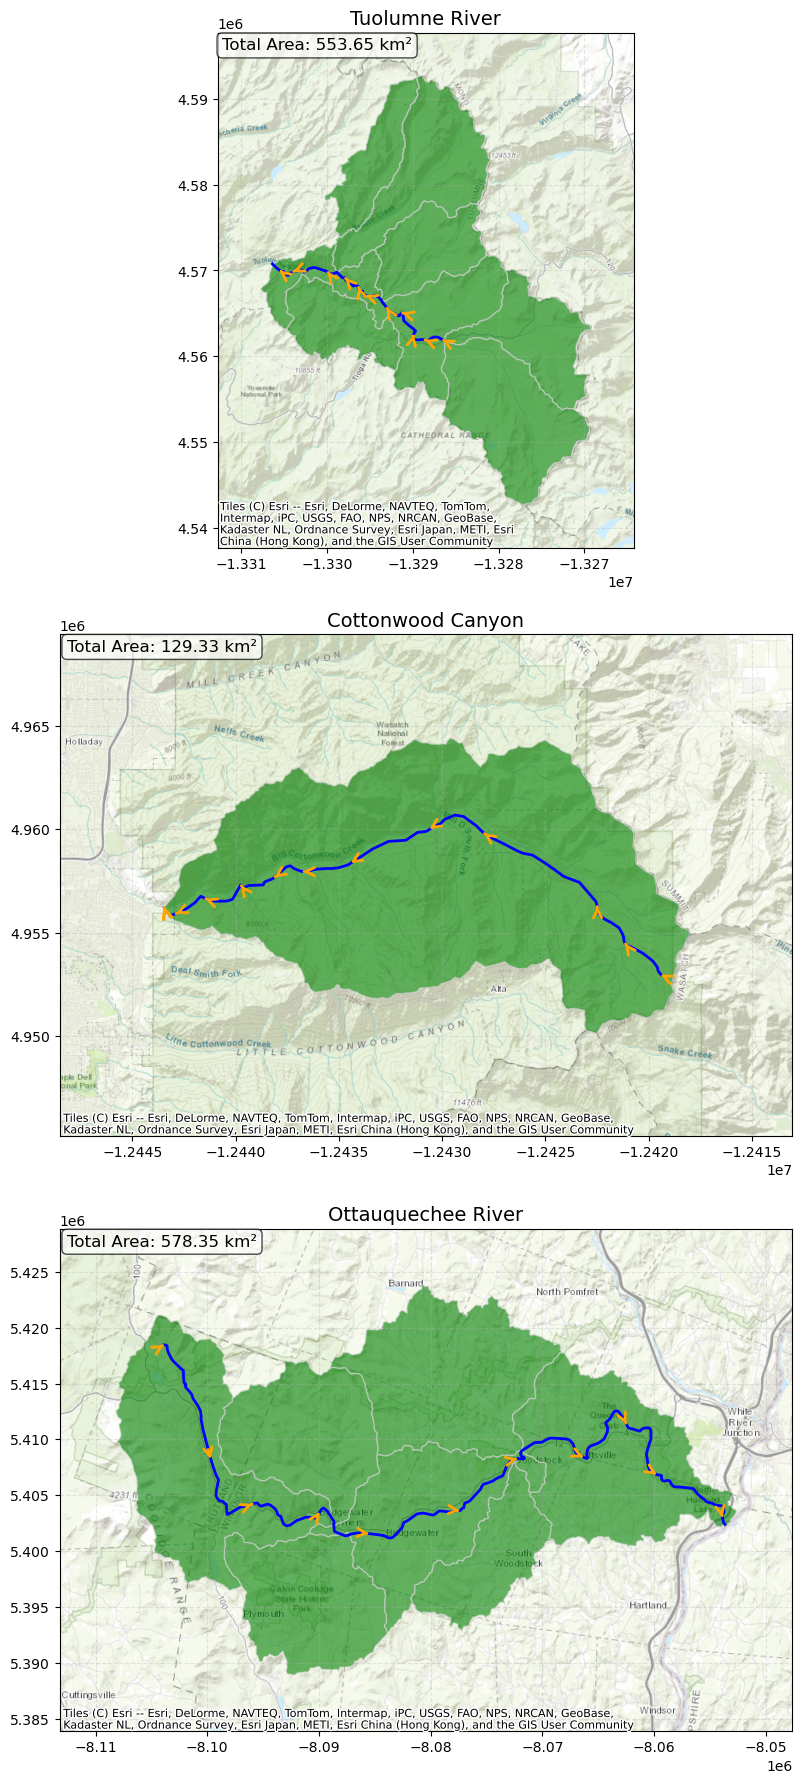

In [34]:
from utils import plot_watersheds_with_flowlines

watershed_files = {
    "Tuolumne River": {
        "watershed": "./watersheds/TuolumneRiver.shp",
        "flowline": "./watersheds/TuolumneRiver_flowline.shp"
    },
    "Cottonwood Canyon": {
        "watershed": "./watersheds/CottonwoodCreek.shp",
        "flowline": "./watersheds/CottonwoodCreek_flowline.shp"
    },
    "Ottauquechee River": {
        "watershed": "./watersheds/OttauquecheeRiver.shp",
        "flowline": "./watersheds/OttauquecheeRiver_flowline.shp"
    }
}

plot_watersheds_with_flowlines(watershed_files)


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 1.05em; color: #333; background-color: #f9f9f9; border-left: 4px solid #004080; padding: 16px; margin-top: 20px; line-height: 1.6;">
  <ul style="margin-left: 20px; padding-left: 0;">
    <li><strong>Tuolumne River Watershed (California):</strong> Water flows from southeast to west across a mountainous region within the <em>Sierra Nevada hydro-climatic zone</em>, characterized by snowmelt-driven hydrology.</li>
    <li><strong>Cottonwood Canyon (Utah):</strong> A smaller <em>HUC-12 basin</em> where water flows from east to west through an <em>arid to semi-arid region</em> of the Intermountain West.</li>
    <li><strong>Ottauquechee River Watershed (Vermont):</strong> Water flows from west to east across a <em>humid continental climate</em>, influenced by seasonal precipitation and snowmelt.</li>
  </ul>
  <p style="margin-bottom: 0;">Unlike Cottonwood Canyon, the Tuolumne and Ottauquechee watersheds are both <strong>HUC-10 basins</strong>, reflecting their larger spatial extent and more complex drainage networks.</p>
</div>


Define the period of interest:

In [35]:
start_date='2000-01-01'
end_date='2000-12-31'

## 3. Access Data

<br></br>
<div style="display: flex; align-items: center; margin-bottom: 0.3em;">
  <div style="display: flex; align-items: center;">
    <img src="https://tse2.mm.bing.net/th/id/OIP.-02i2agKqmB5pAPhSRgvegAAAA?r=0&rs=1&pid=ImgDetMain&o=7&rm=3" 
         alt="NOAA Logo" 
         style="height: 50px; margin-right: 16px;">
    <span style="color:#004080; font-size: 24px; font-weight: bold;">Explore and Access CONUS404</span>

  </div>
</div>

<section style="max-width: 800px; line-height: 1.6; font-family: Arial, sans-serif; font-size: 1em; color: #333;">
    <p>
      <strong>CONUS404</strong> is a high-resolution hydro-climate dataset covering over 40 years (water years 1980–2022) of the CONtiguous United States (CONUS) at 4-km resolution, which is developed using Weather Research and Forecasting (WRF) model simulations by the National Center for Atmospheric Research (NCAR) in collaboration with the U.S. Geological Survey (USGS). The Zarr-based version, hosted through the <strong>HyTEST</strong> (Hydro-Terrestrial Earth System Testbed) initiative (a joint effort by USGS and NCAR) is openly accessible via the <a href="https://hytest-org.github.io/hytest/dataset_access/CONUS404_CHANGELOG.html" target="_blank">HyTEST Intake Data Catalog</a>. By leveraging the cloud-native Zarr format of this dataset, users can interact with data on demand using scalable tools like Dask, without downloading entire datasets or requiring credentials. This makes CONUS404 easy to use across diverse computing platforms and well-suited for large-scale, reproducible research workflows.
    </p>
</section>

Navigate the HyTEST's intake catalog to select and open a dataset. In this Jupyter notebook, we will use the `conus404-catalog`. 

In [36]:
# open the hytest data intake catalog
hytest_cat = intake.open_catalog("https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml")
list(hytest_cat)

['conus404-catalog',
 'benchmarks-catalog',
 'conus404-drb-eval-tutorial-catalog',
 'nhm-v1.0-daymet-catalog',
 'nhm-v1.1-c404-bc-catalog',
 'nhm-v1.1-gridmet-catalog',
 'trends-and-drivers-catalog',
 'nhm-prms-v1.1-gridmet-format-testing-catalog',
 'nwis-streamflow-usgs-gages-onprem',
 'nwis-streamflow-usgs-gages-osn',
 'nwm21-streamflow-usgs-gages-onprem',
 'nwm21-streamflow-usgs-gages-osn',
 'nwm21-streamflow-s3',
 'geofabric_v1_1-zip-osn',
 'geofabric_v1_1_POIs_v1_1-osn',
 'geofabric_v1_1_TBtoGFv1_POIs-osn',
 'geofabric_v1_1_nhru_v1_1-osn',
 'geofabric_v1_1_nhru_v1_1_simp-osn',
 'geofabric_v1_1_nsegment_v1_1-osn',
 'gages2_nndar-osn',
 'wbd-zip-osn',
 'huc12-geoparquet-osn',
 'huc12-gpkg-osn',
 'nwm21-scores',
 'lcmap-s3',
 'rechunking-tutorial-osn',
 'pointsample-tutorial-sites-osn',
 'pointsample-tutorial-output-osn']

<div style="font-family: Arial, sans-serif; font-size: 16px; line-height: 1.6; color: #333;">
    
  <p>
    Open the <code>conus404-catalog</code> sub-catalog to see available datasets. A sub-catalog may contain a set of datasets for a particular use case. 
    For example, the CONUS404 datasets (at different time steps and storage locations) are stored in their own sub-catalog  
    (<a href="https://hytest-org.github.io/hytest/dataset_access/CONUS404_ACCESS.html" target="_blank">learn more</a>).
  </p>
</div>


In [37]:
cat = hytest_cat['conus404-catalog']
list(cat)

['conus404-hourly-onprem-hw',
 'conus404-hourly-osn',
 'conus404-daily-diagnostic-onprem-hw',
 'conus404-daily-diagnostic-osn',
 'conus404-daily-onprem-hw',
 'conus404-daily-osn',
 'conus404-monthly-onprem-hw',
 'conus404-monthly-osn',
 'conus404-hourly-ba-onprem-hw',
 'conus404-hourly-ba-osn',
 'conus404-daily-ba-onprem-hw',
 'conus404-daily-ba-osn',
 'conus404-pgw-hourly-onprem-hw',
 'conus404-pgw-hourly-osn',
 'conus404-pgw-daily-diagnostic-onprem-hw',
 'conus404-pgw-daily-diagnostic-osn',
 'conus404-pgw-daily-onprem-hw',
 'conus404-pgw-daily-osn']

<br>
  <p>
    In this Jupyter Notebook, we will work with hourly datasets on the Open Storage Network  (OSN) pod, which does not need any credentials to access the data. 
    Also, we will focus on the bias-adjusted dataset for the purpose of this notebook 
    (<code>conus404-hourly-ba-osn</code>), which has been revised to include 43 years of data at 1-kilometer grid spacing. This is a dataset of historical conditions (water years 1980–2022, October 1, 1979–September 30, 2022) and has sufficient temporal and spatial detail to make it appropriate for forcing hydrological models and conducting meteorological analyses 
    (<a href="https://www.sciencebase.gov/catalog/item/64f77cad34ed30c20544c18" target="_blank">view source</a>).
  </p>
</br>

Select the dataset and preview its metadata

In [38]:
dataset = 'conus404-hourly-ba-osn' 
print(f"Reading {dataset} metadata...", end='')
ds_conus404 = cat[dataset].to_dask().metpy.parse_cf()
ds_conus404

Reading conus404-hourly-ba-osn metadata...

/home/jovyan/conda_envs/conus404-env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/jovyan/conda_envs/conus404-env/lib/python3.12/site-packages/metpy/xarray.py:812: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  subset = xr.merge([self.parse_cf(single_varname, coordinates=coordinates)


<xarray.Dataset> Size: 80TB
Dimensions:    (time: 376945, x: 4608, y: 3840)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-10-01 ... 2022-10-01
  * x          (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y          (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
    metpy_crs  object 8B Projection: lambert_conformal_conic
Data variables:
    RAINRATE   (time, y, x) float32 27TB dask.array<chunksize=(144, 175, 175), meta=np.ndarray>
    T2D        (time, y, x) float64 53TB dask.array<chunksize=(144, 175, 175), meta=np.ndarray>
    crs        int32 4B ...
Attributes:
    NWM_version_number:         v2.1
    model_configuration:        CONUS404_tpBiasCorr
    model_initialization_time:  1979-09-30_23:00:00
    model_output_type:          forcing
    model_output_valid_time:    1979-10-01_00:00:00
    model_total_valid_times:    744.0

Notice that this loaded very fast. That’s because it performed a “lazy” load of the data, i.e. only the metadata was loaded. Data values will not be accessed until computations are performed.

In [39]:
print(f'Total Size of .........: {ds_conus404.nbytes/1e12:.1f} TB')
print(f'Size Loaded into Memory: {sys.getsizeof(ds_conus404)} bytes')

Total Size of .........: 80.0 TB
Size Loaded into Memory: 120 bytes


Check the precipitation variable

In [40]:
ds_conus404.RAINRATE

<xarray.DataArray 'RAINRATE' (time: 376945, y: 3840, x: 4608)> Size: 27TB
dask.array<open_dataset-RAINRATE, shape=(376945, 3840, 4608), dtype=float32, chunksize=(144, 175, 175), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-10-01 ... 2022-10-01
  * x          (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y          (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
    metpy_crs  object 8B Projection: lambert_conformal_conic
Attributes:
    cell_methods:   time: mean
    grid_mapping:   crs
    long_name:      Surface Precipitation Rate
    remap:          remapped via ESMF regrid_with_weights: Bilinear
    standard_name:  precipitation_flux
    units:          mm s^-1

Check the spatial resolution of the gridded data along the y dimension

In [41]:
ds_conus404.y[1]-ds_conus404.y[0]

<xarray.DataArray 'y' ()> Size: 8B
array(1000.)
Coordinates:
    metpy_crs  object 8B Projection: lambert_conformal_conic

<p>
  <strong>So far</strong>, we have demonstrated how to access this high-value dataset and explore its dimensions, coordinates, variables, and metadata.
  In the next section, we'll shift focus to accessing the <strong>AORC</strong> dataset. 
  Once both datasets are prepared, we will return to <code>ds_conus404</code> and load the actual data into memory for further analysis.
</p>


<div style="display: flex; align-items: center; margin-bottom: 0.3em;">
  <div style="display: flex; align-items: center;">
    <img src="https://www.noaa.gov/sites/default/files/2022-03/noaa_emblem_logo-2022.png" 
         alt="NOAA Logo" 
         style="height: 50px; margin-right: 16px;">
    <span style="color:#004080; font-size: 24px; font-weight: bold;">Explore and Access AORC</span>

  </div>
</div>

<section style="max-width: 800px; line-height: 1.6; font-family: Arial, sans-serif; font-size: 1em; color: #333;">
      <p> <strong>AORC</strong>, developed by NOAA’s National Weather Service Office of Water Prediction, provides high-resolution (1-km), hourly gridded meteorological data across the conterminous United States (CONUS), Alaska, and neighboring regions that contribute to U.S. watersheds. AORC integrates observations and model estimates to generate the best available inputs for hydrologic modeling from 1979 to the near-present. In this notebook, we will work with version 1.1 of AORC, which is publicly available as part of the <a href="https://registry.opendata.aws/noaa-nwm-retrospective/" target="_blank">NOAA National Water Model v3.0 Retrospective archive</a> on AWS. These data are also accessible in <strong>Zarr</strong> format, allowing efficient, cloud-native access and scalable analysis using tools like <code>xarray</code>.
    </p>
</section>


Define a few parameters for accessing the specific variable that we are interested in.

In [42]:
bucket_url = 's3://noaa-nwm-retrospective-3-0-pds'
region = 'CONUS'
variable = 'precip'

In [43]:
print(f"Reading AORC metadata...", end='')
ds_aorc = xr.open_zarr(
    store='s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/forcing/precip.zarr',
    consolidated=True,
    storage_options={"anon": True}
)

ds_aorc

Reading AORC metadata...

<xarray.Dataset> Size: 27TB
Dimensions:   (time: 385704, y: 3840, x: 4608)
Coordinates:
  * time      (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x         (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y         (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
Data variables:
    RAINRATE  (time, y, x) float32 27TB dask.array<chunksize=(672, 350, 350), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

Preview the size

In [44]:
print(f'Total Size of .........: {ds_aorc.nbytes/1e12:.1f} TB')
print(f'Size Loaded into Memory: {sys.getsizeof(ds_aorc)} bytes')

Total Size of .........: 27.3 TB
Size Loaded into Memory: 120 bytes


View the precipitation data

In [45]:
ds_aorc.RAINRATE

<xarray.DataArray 'RAINRATE' (time: 385704, y: 3840, x: 4608)> Size: 27TB
dask.array<open_dataset-RAINRATE, shape=(385704, 3840, 4608), dtype=float32, chunksize=(672, 350, 350), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x        (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y        (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
Attributes:
    cell_methods:    time: mean
    esri_pe_string:  PROJCS["Lambert_Conformal_Conic",GEOGCS["GCS_Sphere",DAT...
    grid_mapping:    crs
    long_name:       Surface Precipitation Rate
    proj4:           +proj=lcc +units=m +a=6370000.0 +b=6370000.0 +lat_1=30.0...
    remap:           remapped via ESMF regrid_with_weights: Bilinear
    standard_name:   precipitation_flux
    units:           mm s^-1

## 4. Aligning Gridded Datasets with Watershed Boundaries

To conduct meaningful watershed-scale analysis, it is important to ensure that both gridded datasets are properly aligned with the boundaries of the three selected watersheds. This process involves several important steps: first, inspecting and comparing the coordinate reference systems (CRS) used by each dataset; second, verifying the spatial domain and resolution to ensure consistency in coverage; and finally, clipping each dataset to the watershed extent. By harmonizing spatial properties, we can ensure that comparisons between datasets are accurate and representative of the same geographic area. The steps below walk through this alignment process.

Preview the domain boundaries of both gridded dataset

In [46]:
print("\n Domain Boundaries for CONUS404 Dataset")
print("------------------------------------------")
print(f"X Range: [{ds_conus404.x.min().item():.2f}, {ds_conus404.x.max().item():.2f}]")
print(f"Y Range: [{ds_conus404.y.min().item():.2f}, {ds_conus404.y.max().item():.2f}]")

print("\n Domain Boundaries for AORC Dataset")
print("--------------------------------------")
print(f"X Range: [{ds_aorc.x.min().item():.2f}, {ds_aorc.x.max().item():.2f}]")
print(f"Y Range: [{ds_aorc.y.min().item():.2f}, {ds_aorc.y.max().item():.2f}]")



 Domain Boundaries for CONUS404 Dataset
------------------------------------------
X Range: [-2303499.25, 2303500.75]
Y Range: [-1919500.38, 1919499.62]

 Domain Boundaries for AORC Dataset
--------------------------------------
X Range: [-2303499.25, 2303500.75]
Y Range: [-1919500.38, 1919499.62]


Display the Coordinate Reference System (CRS) used by each dataset

In [47]:
print("CRS (WKT) for CONUS404 dataset:\n-------------------------------")
print(ds_conus404.crs.attrs['crs_wkt'])

print("\nCRS (ESRI PE String) for AORC dataset:\n--------------------------------------")
print(ds_aorc.crs.attrs['esri_pe_string'])


CRS (WKT) for CONUS404 dataset:
-------------------------------
PROJCRS["Lambert_Conformal_Conic",BASEGEOGCRS["Unknown datum based upon the Authalic Sphere",DATUM["Not specified (based on Authalic Sphere)",ELLIPSOID["Sphere",6370000,0,LENGTHUNIT["metre",1]],ID["EPSG",6035]],PRIMEM["Greenwich",0,ANGLEUNIT["Degree",0.0174532925199433]]],CONVERSION["unnamed",METHOD["Lambert Conic Conformal (2SP)",ID["EPSG",9802]],PARAMETER["Easting at false origin",0,LENGTHUNIT["metre",1],ID["EPSG",8826]],PARAMETER["Northing at false origin",0,LENGTHUNIT["metre",1],ID["EPSG",8827]],PARAMETER["Longitude of false origin",-97,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8822]],PARAMETER["Latitude of 1st standard parallel",30,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8823]],PARAMETER["Latitude of 2nd standard parallel",60,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8824]],PARAMETER["Latitude of false origin",40,ANGLEUNIT["Degree",0.0174532925199433],ID["EPSG",8821]]],CS[Cartesian,2],AXIS["(E)"

Although both datasets already contain spatial coordinate information and use the `Lambert Conformal Conic` projection, their coordinate reference systems (CRS) differ slightly in format. One specified as a WKT string (`crs_wkt`) and the other as an ESRI PE string (`esri_pe_string`). These subtle differences can lead to compatibility issues when performing spatial operations such as `clip()` or `reproject()` with `rioxarray`.

To ensure consistent and reliable behavior, it is best practice to normalize the CRS using `pyproj.CRS.from_wkt()` or `pyproj.CRS.from_string()` and then explicitly apply it to the dataset using `ds.rio.write_crs(...)`. This step is important even if the dataset includes a `spatial_ref` coordinate, because many spatial operations in `rioxarray` rely on the presence of a properly assigned CRS via `.rio.write_crs(...)` to function correctly.

In [48]:
# Normalize CRS from WKT (CONUS404)
crs_conus = pyproj.CRS.from_wkt(ds_conus404.crs.attrs['crs_wkt'])

# Normalize CRS from ESRI string (AORC)
crs_aorc = pyproj.CRS.from_wkt(ds_aorc.crs.attrs['esri_pe_string'])

# Confirm equality
print(crs_conus == crs_aorc)  # → True if both are equivalent

# Apply CRS to both datasets (use .rio.write_crs if you already have spatial coords)
ds_conus404.rio.write_crs(crs_conus, inplace=True);
ds_aorc.rio.write_crs(crs_aorc, inplace=True);


True


Print the compact text format for describing CRS used by the PROJ library.

In [49]:
print(f'CONUS404 CRS:\n-----\n{ds_conus404.rio.crs.to_proj4()}')
print(f'AORC CRS:\n-----\n{ds_aorc.rio.crs.to_proj4()}')

CONUS404 CRS:
-----
+proj=lcc +lat_0=40 +lon_0=-97 +lat_1=30 +lat_2=60 +x_0=0 +y_0=0 +R=6370000 +units=m +no_defs=True
AORC CRS:
-----
+proj=lcc +lat_0=40 +lon_0=-97 +lat_1=30 +lat_2=60 +x_0=0 +y_0=0 +R=6370000 +units=m +no_defs=True


Next, we need to ensure that the CRS used by the AORC and CONUS404 datasets matches the coordinate reference system of the watershed shapefiles. Since these coordinate systems differ, we will need to reproject the watershed geometries or the datasets accordingly before proceeding with spatial operations.

In [50]:
watershed_paths = {
    "Tuolumne River": "./watersheds/TuolumneRiver.shp",
    "Cottonwood Canyon": "./watersheds/CottonwoodCreek.shp",
    "Ottauquechee River": "./watersheds/OttauquecheeRiver.shp"
}

# Read, print original CRS, reproject, and print updated CRS
gdfs = {}
for name, path in watershed_paths.items():
    gdf = gpd.read_file(path)
    print(f"\nOriginal CRS for {name}:\n-----\n{gdf.crs.to_wkt()}")

    # convert the shapefile into the coordinate system of the xarray datasets
    gdf_proj = gdf.to_crs(ds_aorc.rio.crs)
    print(f"Reprojected CRS for {name}:\n-----\n{gdf_proj.crs.to_wkt()}")
    # we used .to_wkt() instead of .to_proj4() for debugging or comparing purposes
    
    gdfs[name] = gdf_proj  # Store for later use if needed


Original CRS for Tuolumne River:
-----
PROJCRS["WGS 84 / Pseudo-Mercator",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["Popular Visualisation Pseudo-Mercator",METHOD["Popular Visualisation Pseudo Mercator",ID["EPSG",1024]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["False easti

Let's clip both gridded datasets to the spatial extent of the selected watersheds and the defined time period. This can be accomplished using `rioxarray`'s `clip()` method.

In [51]:
gdfs.keys()

dict_keys(['Tuolumne River', 'Cottonwood Canyon', 'Ottauquechee River'])

In [52]:
# Call the function to clip datasets to all watersheds
clipped_watershed_datasets = utils.clip_watershed_data(
    gdfs=gdfs,
    ds_conus404=ds_conus404,
    ds_aorc=ds_aorc,
    start_date=start_date,
    end_date=end_date
)

Processing watershed: Tuolumne River
Processing watershed: Cottonwood Canyon
Processing watershed: Ottauquechee River


Preview the clipped datasets

In [53]:
clipped_watershed_datasets

{'Tuolumne River': {'conus404': <xarray.Dataset> Size: 122MB
  Dimensions:    (time: 8784, x: 29, y: 40)
  Coordinates:
    * time       (time) datetime64[ns] 70kB 2000-01-01 ... 2000-12-31T23:00:00
    * x          (x) float64 232B -1.901e+06 -1.9e+06 ... -1.874e+06 -1.873e+06
    * y          (y) float64 320B 1.95e+04 2.05e+04 2.15e+04 ... 5.75e+04 5.85e+04
      metpy_crs  object 8B Projection: lambert_conformal_conic
      crs        int64 8B 0
  Data variables:
      RAINRATE   (time, y, x) float32 41MB dask.array<chunksize=(24, 40, 29), meta=np.ndarray>
      T2D        (time, y, x) float64 82MB dask.array<chunksize=(24, 40, 29), meta=np.ndarray>
  Attributes:
      NWM_version_number:         v2.1
      model_configuration:        CONUS404_tpBiasCorr
      model_initialization_time:  1979-09-30_23:00:00
      model_output_type:          forcing
      model_output_valid_time:    1979-10-01_00:00:00
      model_total_valid_times:    744.0,
  'aorc': <xarray.Dataset> Size: 41MB
  D

Our datasets are still lazily loaded using `Dask`, especially since we used `from_disk=True` during clipping. Below, we print the estimated total size of the data that would be loaded into memory after clipping and slicing if we were to trigger computation later using `.load()` or `.compute()`.

In [54]:
# display size of metadata from one watershed as an example
print(f'{clipped_watershed_datasets["Cottonwood Canyon"]["conus404"].nbytes/1e6:.1f} MB')
print(f'{clipped_watershed_datasets["Cottonwood Canyon"]["aorc"].nbytes/1e6:.1f} MB')

26.1 MB
8.7 MB


We can visualize the data using Python's `matplotlib` along with `xarray`'s `.plot()` function. Below, we display both precipitation fields for the first time step.

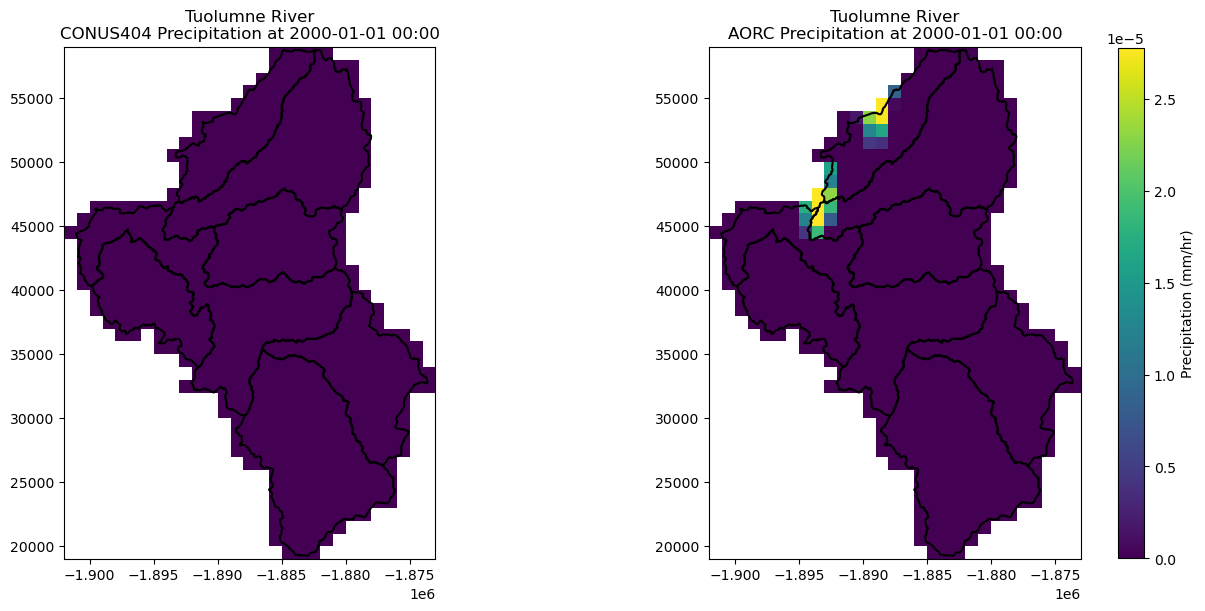

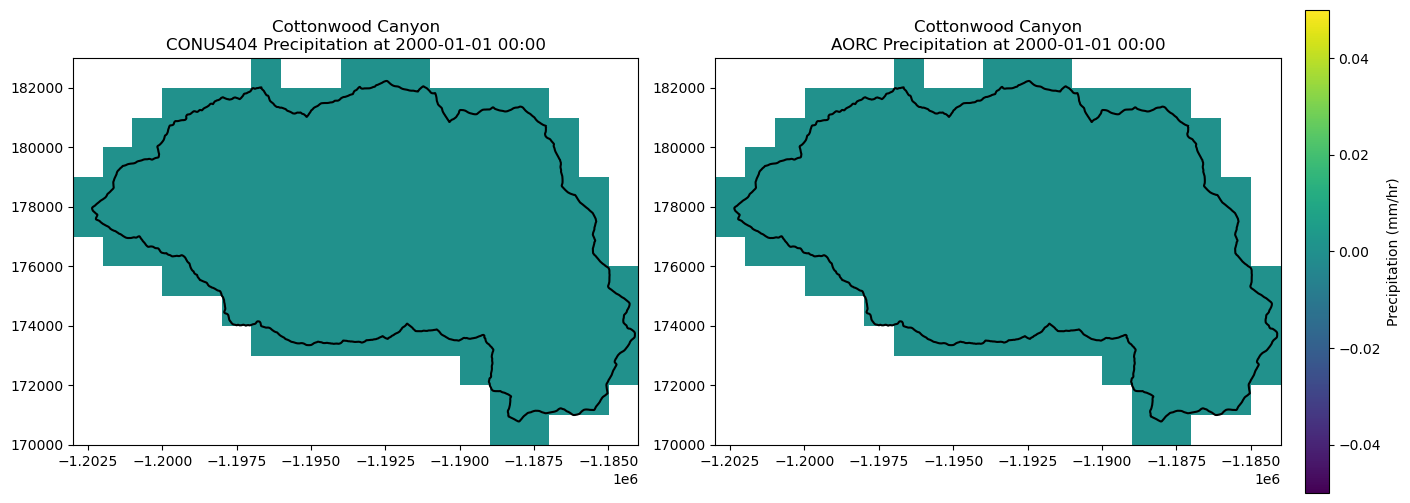

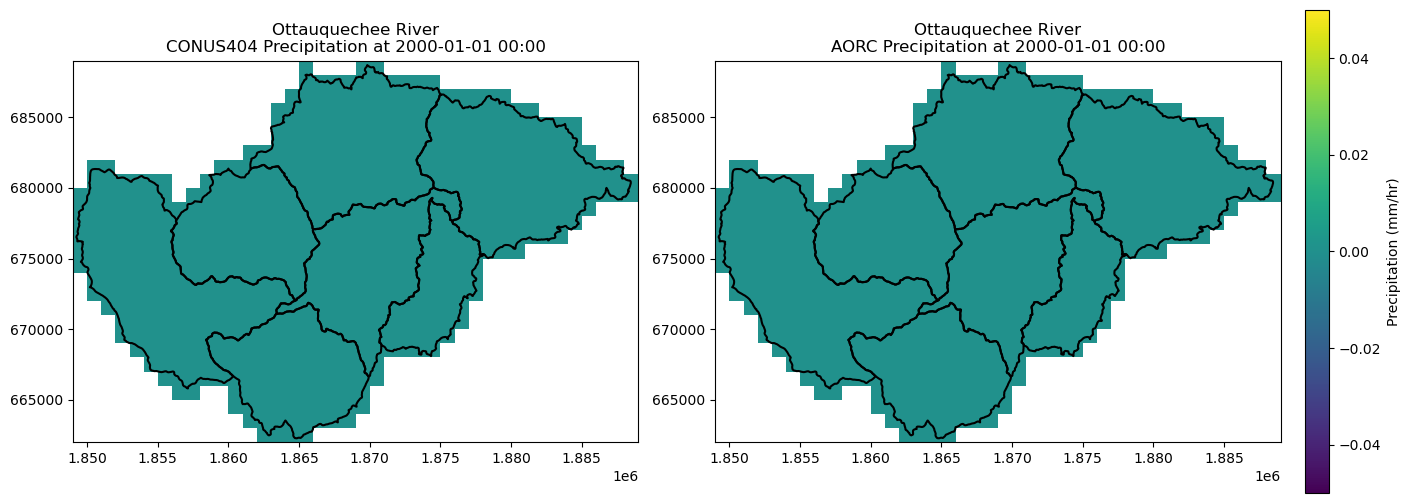

In [55]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="distributed")

utils.plot_watershed_data(
    watershed_name = 'Tuolumne River',
    clipped_data_watersheds = clipped_watershed_datasets, # Clipped data contains only xarray Datasets
    gdfs_watersheds = gdfs, # Separate input for GeoDataFrames
    variable_of_interest = 'RAINRATE',
    time_index = 0,
    cmap = 'viridis'
)

utils.plot_watershed_data(
    watershed_name = 'Cottonwood Canyon',
    clipped_data_watersheds = clipped_watershed_datasets, # Clipped data contains only xarray Datasets
    gdfs_watersheds = gdfs, # Separate input for GeoDataFrames
    variable_of_interest = 'RAINRATE',
    time_index = 0,
    cmap = 'viridis'
)

utils.plot_watershed_data(
    watershed_name = 'Ottauquechee River',
    clipped_data_watersheds = clipped_watershed_datasets, # Clipped data contains only xarray Datasets
    gdfs_watersheds = gdfs, # Separate input for GeoDataFrames
    variable_of_interest = 'RAINRATE',
    time_index = 0,
    cmap = 'viridis'
)

<p>
  When working with large datasets using tools like <code>Zarr</code>, <code>xarray</code>, and <code>Dask</code>, it is important to understand how <strong>chunks</strong> work—especially before triggering computations with <code>.load()</code> or <code>.compute()</code>. A <strong>chunk</strong> is a small block of data representing a subset of the entire array, stored and processed independently. Managing chunk size is crucial because if chunks are too large, they can exceed your available memory and cause crashes or significant slowdowns. On the other hand, if chunks are too small, the overhead of managing many tasks can also reduce overall performance.
</p>

<p>
  Ideally, chunk shapes should align with how you plan to access or analyze your data. For instance, if your typical workflow involves slicing along the <code>time</code> dimension, but your chunks are stored as long time-series per location (e.g., <code>time: 1000</code>), you may experience degraded performance. Rechunking to smaller time windows (e.g., <code>time: 50</code>) can significantly improve computational efficiency.
</p>

<p>
  You should consider rechunking if your computations feel very slow, if the current chunking structure does not align well with your analysis patterns, or if you get warnings or memory-related errors when calling <code>.load()</code> or <code>.compute()</code>. Understanding the role of chunking can help you make better use of available resources and improve the speed and memory usage in your workflows.
</p>


<h4>What Do “Chunks” Mean in Each Tool?</h4>
<ul>
  <li><strong>Zarr:</strong> Stores data in chunked format on disk.</li>
  <li><strong>xarray (with Dask):</strong> Operates on data chunk-by-chunk instead of loading everything into memory.</li>
  <li><strong>Dask:</strong> Treats each chunk as a task in a computation graph, enabling parallel execution and memory efficiency.</li>
</ul>


Check the chunks

In [56]:
# display the chunks from one watershed as an example
print("CONUS404 Chunk Structure:")
print("-" * 40)
print(clipped_watershed_datasets["Cottonwood Canyon"]["conus404"].chunks)
print("\nAORC (Clipped) Chunk Structure:")
print("-" * 40)
print(clipped_watershed_datasets["Cottonwood Canyon"]["aorc"].chunks)

CONUS404 Chunk Structure:
----------------------------------------
Frozen({'time': (24, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 120), 'y': (10, 3), 'x': (19,)})

AORC (Clipped) Chunk Structure:
----------------------------------------
Frozen({'time': (120, 672, 672, 672, 672, 672, 672, 672, 672, 672, 672, 672, 672, 600), 'y': (10, 3), 'x': (19,)})


Note that you can rechunk the time dimension based on your machine to reduce task graph complexity if needed.

In [57]:
%%time
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="distributed")

def process(ds):
    return ds["RAINRATE"].chunk({"x": -1, "y": -1, "time": 720})

# Compute sequentially per watershed/source to keep graphs small
computed_rainrate = {}
for ws, sources in clipped_watershed_datasets.items():
    computed_rainrate[ws] = {}
    for src, ds in sources.items():
        da = process(ds)
        da = client.persist(da) 
        computed_rainrate[ws][src] = da.compute()

CPU times: user 4.93 s, sys: 622 ms, total: 5.55 s
Wall time: 25.8 s


Check the size of the `time` dimension for both datasets:

In [58]:
len(computed_rainrate["Cottonwood Canyon"]["aorc"].time), len(computed_rainrate["Cottonwood Canyon"]["aorc"].time)

(8784, 8784)

## 5. Investigating Biases, Variability, and Correlations

<p>
  In this section, we explore the <strong>statistical agreement and spatial-temporal differences</strong> between the two precipitation datasets by analyzing a suite of key metrics. These metrics are grouped into three broad categories: 
  (1) <strong>central tendency and spread</strong>: including domain-averaged mean, standard deviation (std), and interquartile range (IQR); 
  (2) <em>error-based metrics</em>: such as bias and root mean square error (RMSE); and 
  (3) <em>correlation measures</em>: focusing on pixel-wise anomaly correlation to assess temporal agreement across space. 
  Together, these help us assess whether the two datasets differ systematically (bias), how variable they are over time and space (spread), and how strongly they co-vary (correlation).
</p>


The following shows the mathematical representation of pixelwise Pearson Correlation, which is called from `utils.py`.

### Pixelwise Pearson Correlation

For each pixel $(i,j)$, let the two time series be:

$$
X_{t}^{(i,j)}, \quad Y_{t}^{(i,j)}, \quad t = 1, 2, \dots, n
$$

##### 1. Compute Means and Anomalies
$$
\bar{X}^{(i,j)} = \frac{1}{n}\sum_{t=1}^{n} X_{t}^{(i,j)}, 
\qquad
\bar{Y}^{(i,j)} = \frac{1}{n}\sum_{t=1}^{n} Y_{t}^{(i,j)}
$$

$$
X'_{t} = X_{t}^{(i,j)} - \bar{X}^{(i,j)}, 
\qquad
Y'_{t} = Y_{t}^{(i,j)} - \bar{Y}^{(i,j)}
$$

##### 2. Compute Standard Deviations
$$
\sigma_X^{(i,j)} = \sqrt{\frac{1}{n}\sum_{t=1}^{n} \big(X'_{t}\big)^{2}},
\qquad
\sigma_Y^{(i,j)} = \sqrt{\frac{1}{n}\sum_{t=1}^{n} \big(Y'_{t}\big)^{2}}
$$

##### 3. Compute Numerator (Covariance)
$$
\text{Cov}^{(i,j)}(X,Y) = \frac{1}{n}\sum_{t=1}^{n} X'_{t} \, Y'_{t}
$$

##### 4. Compute Pearson Correlation
$$
r^{(i,j)} = \frac{\text{Cov}^{(i,j)}(X,Y)}{\sigma_X^{(i,j)} \, \sigma_Y^{(i,j)}}
$$

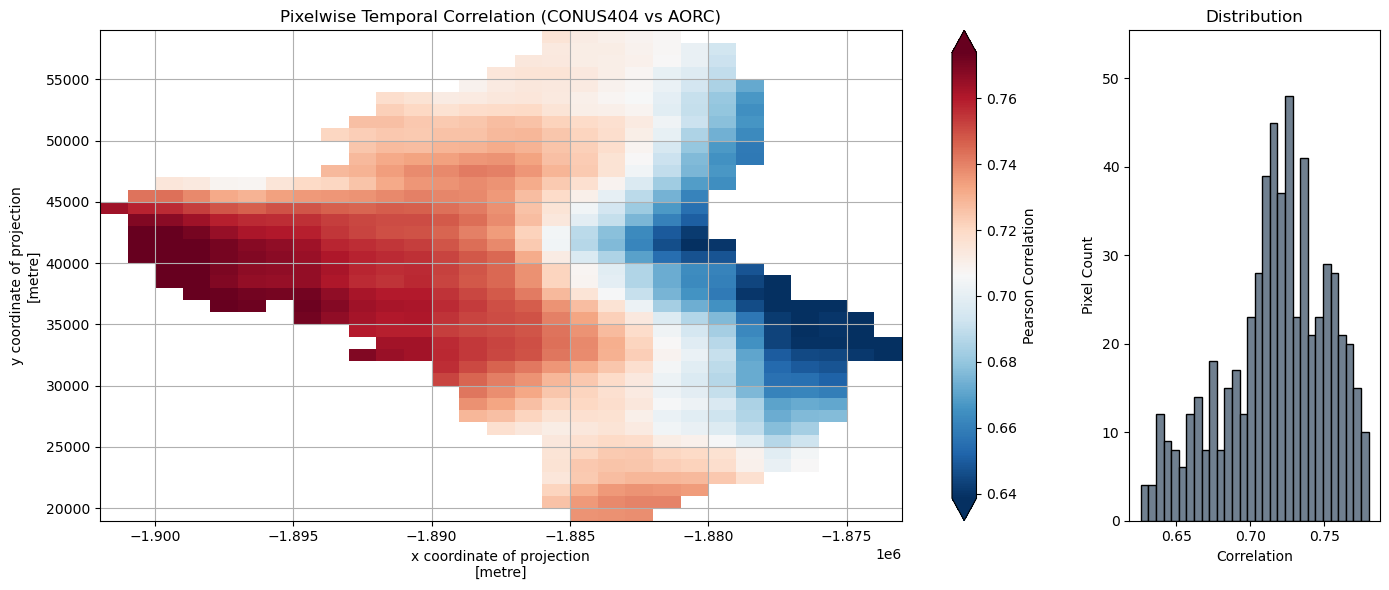

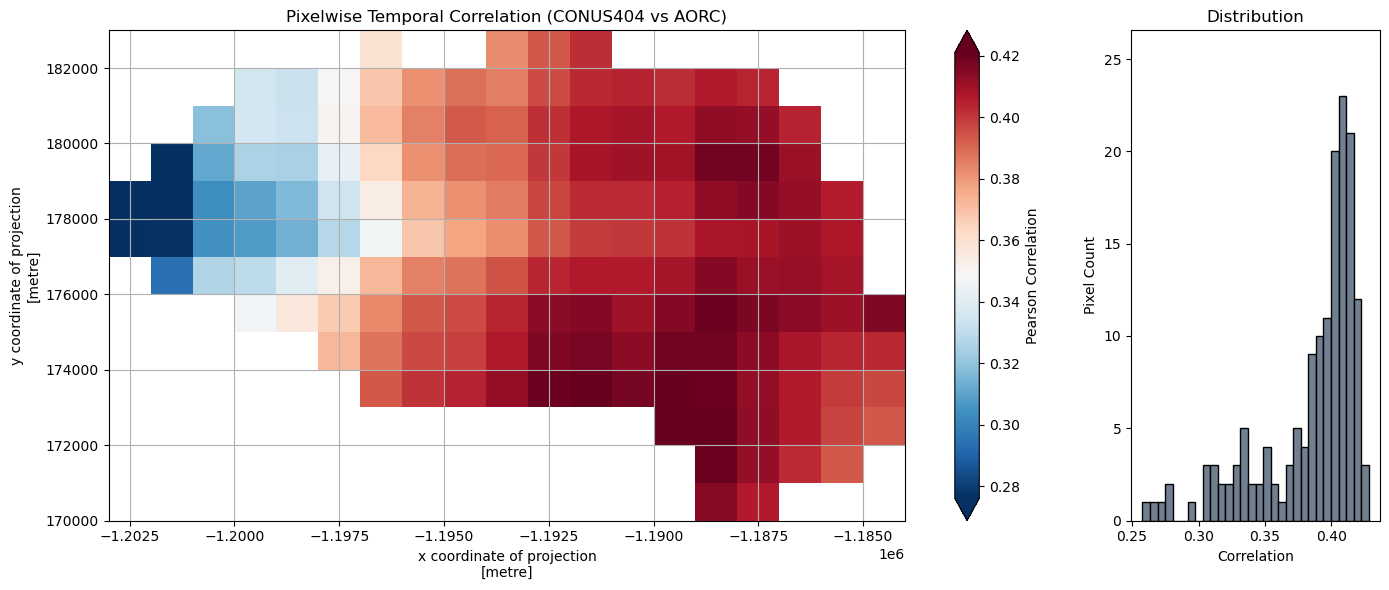

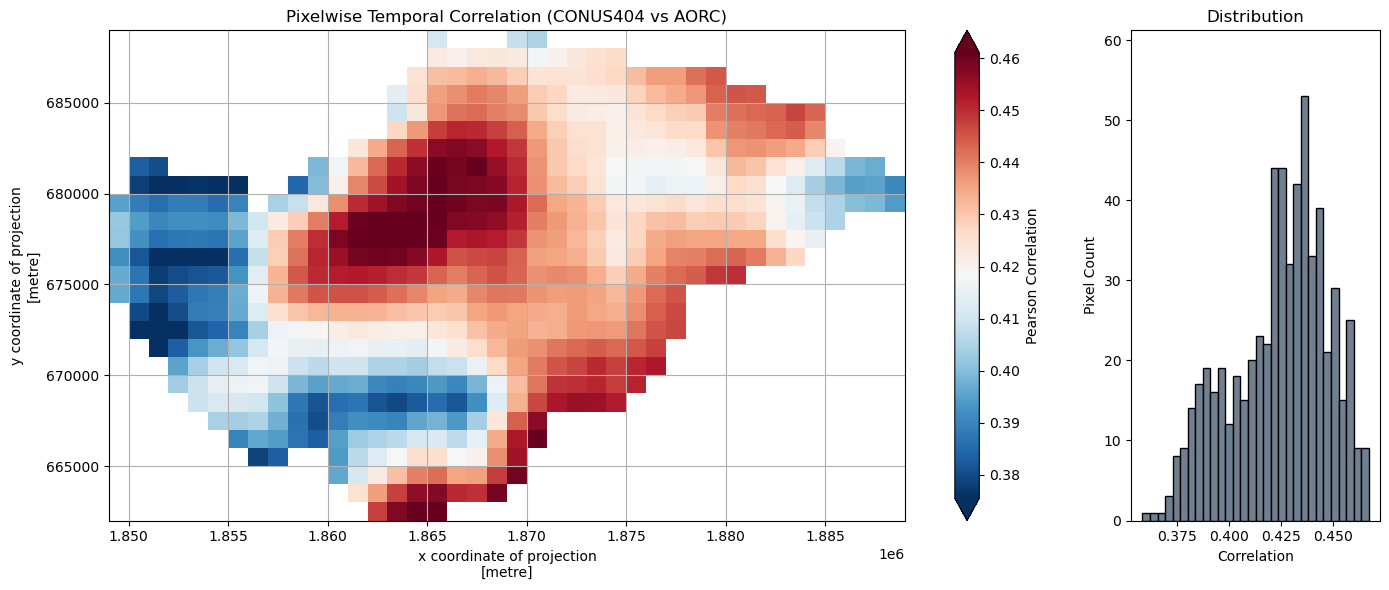

In [59]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")

corr = utils.plot_pixelwise_correlation(computed_rainrate["Tuolumne River"]["conus404"], 
                                        computed_rainrate["Tuolumne River"]["aorc"], 
                                        min_std=1e-6, 
                                        min_valid_obs=2)
corr = utils.plot_pixelwise_correlation(computed_rainrate["Cottonwood Canyon"]["conus404"], 
                                        computed_rainrate["Cottonwood Canyon"]["aorc"], 
                                        min_std=1e-6, 
                                        min_valid_obs=2)
corr = utils.plot_pixelwise_correlation(computed_rainrate["Ottauquechee River"]["conus404"], 
                                        computed_rainrate["Ottauquechee River"]["aorc"], 
                                        min_std=1e-6, 
                                        min_valid_obs=2)

# The warning RuntimeWarning: Degrees of freedom <= 0 for 
# slice is not about the global count of valid time steps
# It is about specific pixels that have NaN at every time step after clipping.

The middle image shows the result of a pixelwise temporal Pearson correlation between two gridded datasets over the Cottonwood Canyon watershed. Each grid cell represents a spatial location with a size of 1 km within the watershed. The color indicates the Pearson correlation coefficient (ranging from approximately 0.35 to 0.45 in this example). Higher values (redder shades) indicate stronger agreement in the time series at those locations, while lower values (bluer shades) reflect weaker agreement. Since water flows from east to west in this region, it appears that correlation is lower over higher elevations.

The histogram on the right shows the distribution of correlation values across all pixels. Most values fall in the range of 0.38 to 0.44, indicating moderate but consistent agreement across the domain. No extreme outliers (e.g., negative values or values greater than 0.5) are observed.

This visualization serves as a useful diagnostic for identifying where each dataset may be more or less reliable and whether further bias correction or harmonization is necessary. 

Now, we can compute and plot other **spatial statistics** for each dataset (e.g., mean, standard deviation). For example, for the Cottonwood Canyon:

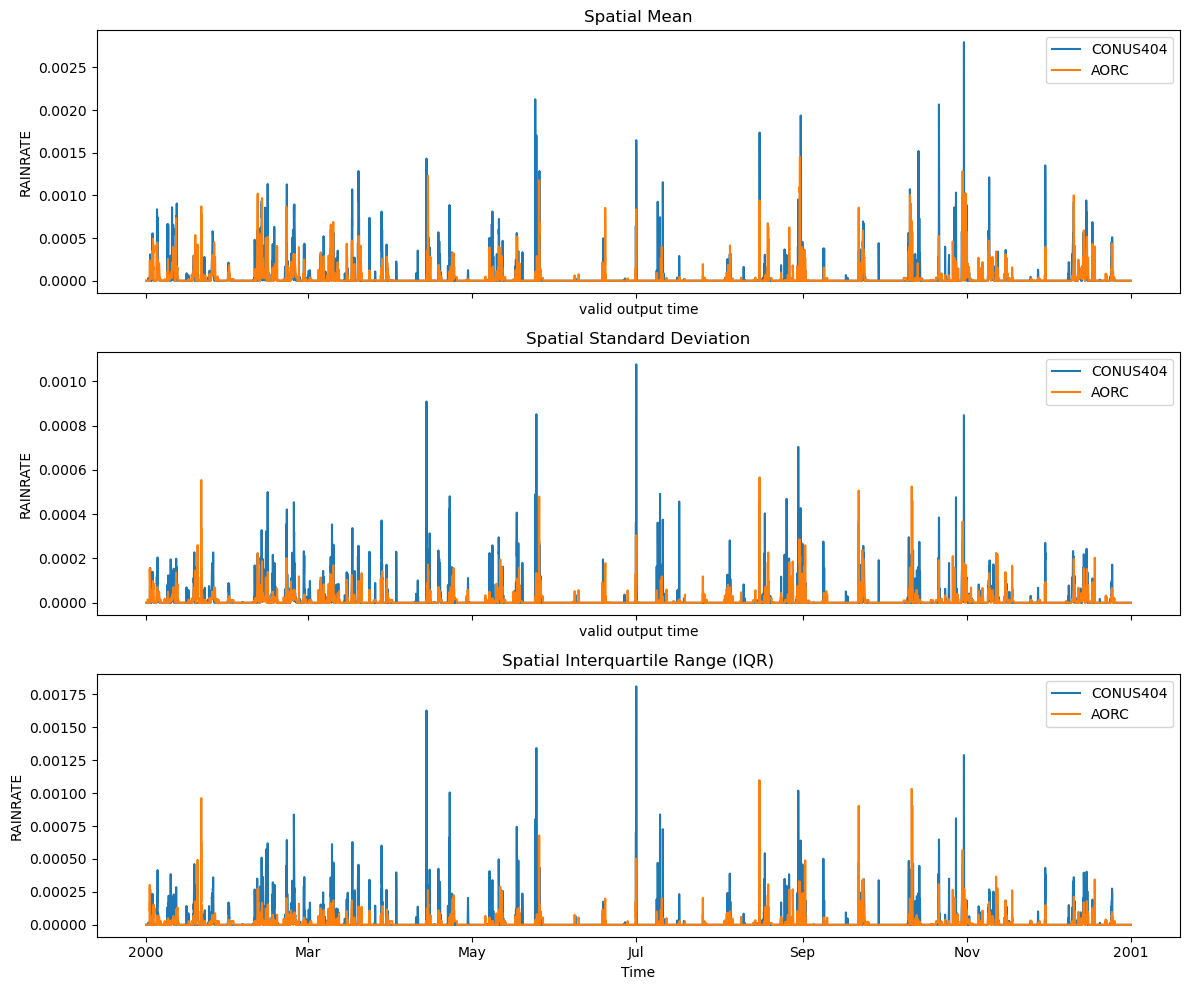

In [60]:
mean1 = utils.compute_mean(computed_rainrate["Cottonwood Canyon"]["conus404"])
mean2 = utils.compute_mean(computed_rainrate["Cottonwood Canyon"]["aorc"])

std1 = utils.compute_std(computed_rainrate["Cottonwood Canyon"]["conus404"])
std2 = utils.compute_std(computed_rainrate["Cottonwood Canyon"]["aorc"])

iqr1 = utils.compute_iqr(computed_rainrate["Cottonwood Canyon"]["conus404"])
iqr2 = utils.compute_iqr(computed_rainrate["Cottonwood Canyon"]["aorc"])

utils.plot_spatial_stats(
    mean1, mean2,
    std1, std2,
    iqr1, iqr2)

## 6. Saving Analysis Data to HydroShare

Once this is done, we can now save the analysis results back to HydroShare in a programmtic and structured way. First, let's import the relevant libraries:


In [61]:
def summarize_computed_rainrate(data_dict):
    rows = []
    total_bytes = 0
    
    for ws, sources in data_dict.items():
        for src, da in sources.items():
            # size in bytes
            size_bytes = da.nbytes
            total_bytes += size_bytes
            rows.append({
                "Watershed": ws,
                "Source": src,
                "Shape": da.shape,
                "Dtype": da.dtype,
                "Size_MB": round(size_bytes / 1e6, 2)
            })
    
    # pretty print
    print("Summary of computed_rainrate:\n")
    for r in rows:
        print(f"{r['Watershed']:20s} | {r['Source']:10s} | "
              f"shape={r['Shape']} | dtype={r['Dtype']} | "
              f"{r['Size_MB']:8.2f} MB")
    
    print(f"\nTotal size: {total_bytes / 1e9:.2f} GB")

summarize_computed_rainrate(computed_rainrate)


Summary of computed_rainrate:

Tuolumne River       | conus404   | shape=(8784, 40, 29) | dtype=float32 |    40.76 MB
Tuolumne River       | aorc       | shape=(8784, 40, 29) | dtype=float32 |    40.76 MB
Cottonwood Canyon    | conus404   | shape=(8784, 13, 19) | dtype=float32 |     8.68 MB
Cottonwood Canyon    | aorc       | shape=(8784, 13, 19) | dtype=float32 |     8.68 MB
Ottauquechee River   | conus404   | shape=(8784, 27, 40) | dtype=float32 |    37.95 MB
Ottauquechee River   | aorc       | shape=(8784, 27, 40) | dtype=float32 |    37.95 MB

Total size: 0.17 GB


In [63]:
ds_1 = computed_rainrate["Cottonwood Canyon"]["aorc"].to_dataset()
ds_2 = computed_rainrate["Cottonwood Canyon"]["conus404"].to_dataset()

Clean metadata in the CONUS404 dataset that will cause problems when saving.

* metpy added CRS information that will be problematic. This is saved in the metpy_crs variable as well as the grid_mapping attribute in other variables. It needs to be removed in both places.
* Since we're changing the chunking scheme for the data we save to disk (zarr), we need to first remove the metadata related to the original chunking scheme from when we loaded the data originally. Otherwise, we'll run into conflicting chunk metadata when saving our zarr to disk.

In [64]:
def clean_and_rechunk(ds):
    if 'metpy_crs' in ds.coords:
        ds = ds.drop_vars("metpy_crs")
    
    # Remove 'grid_mapping' attribute from all variables (like RAINRATE)
    for var in ds.data_vars:
        ds[var].attrs.pop("grid_mapping", None)  # safely remove if it exists
    
    # Remove all leftover .encoding entries to avoid chunk metadata conflict
    for var in ds.data_vars:
        ds[var].encoding.clear()
    
    # re-chunk
    ds = ds.chunk({'time': 1000, 'y': ds.sizes['y'], 'x': ds.sizes['x']})

    return ds

Convert each DataArray in our `computed_rainrate` dictionary to an Xarray `DataSet`, then clean `metpy_crs` and `grid_mapping` variables, and finally rechunk the `time` variable in blocks of 1000 elements.

In [71]:
for watershed in computed_rainrate.keys():
    for met_name, ds in computed_rainrate[watershed].items():
        print(f'Cleaning and rechunking - {watershed}:{met_name}')
        computed_rainrate[watershed][met_name] = clean_and_rechunk(ds.to_dataset())

Cleaning and rechunking - Tuolumne River:conus404
Cleaning and rechunking - Tuolumne River:aorc
Cleaning and rechunking - Cottonwood Canyon:conus404
Cleaning and rechunking - Cottonwood Canyon:aorc
Cleaning and rechunking - Ottauquechee River:conus404
Cleaning and rechunking - Ottauquechee River:aorc


Save the cleaned datasets to Zarr (locally).

In [80]:
# define the path for our output data
store_path = 'data.zarr'

In [81]:
import time

write_mode = 'w'
for watershed in computed_rainrate.keys():
    for met_name, ds in computed_rainrate[watershed].items():
        
        # save the DataSet as a group in the Zarr 
        st = time.time()
        print(f'Saving group - {watershed}/{met_name}...', flush=True, end='')
        ds.to_zarr(store_path, mode=write_mode, consolidated=True, group=f'{watershed}/{met_name}')
        print(f'done [{round(time.time() - st, 2)} sec elapsed]')
        # switch to append mode after the first DataSet has been written
        write_mode = 'a'

Saving group - Tuolumne River/conus404...done [0.46 sec elapsed]
Saving group - Tuolumne River/aorc...done [0.59 sec elapsed]
Saving group - Cottonwood Canyon/conus404...done [0.47 sec elapsed]
Saving group - Cottonwood Canyon/aorc...done [0.62 sec elapsed]
Saving group - Ottauquechee River/conus404...done [0.58 sec elapsed]
Saving group - Ottauquechee River/aorc...done [0.71 sec elapsed]


Open the zarr as using datatree so we can inspect the groups.

In [82]:
dt = xr.open_datatree(store_path)
dt.groups

('/',
 '/Cottonwood Canyon',
 '/Ottauquechee River',
 '/Tuolumne River',
 '/Cottonwood Canyon/aorc',
 '/Cottonwood Canyon/conus404',
 '/Ottauquechee River/aorc',
 '/Ottauquechee River/conus404',
 '/Tuolumne River/aorc',
 '/Tuolumne River/conus404')

We can print the structure of the datatree using the `descendants` attribute.

In [88]:
# Print only descendants that have children
for node in dt.descendants:
    if node.children:  # only non-leaf nodes
        print(f'{node}\n')

<xarray.DataTree 'Cottonwood Canyon'>
Group: /Cottonwood Canyon
├── Group: /Cottonwood Canyon/aorc
│       Dimensions:   (time: 8784, y: 13, x: 19)
│       Coordinates:
│           crs       int64 8B ...
│         * time      (time) datetime64[ns] 70kB 2000-01-01 ... 2000-12-31T23:00:00
│         * x         (x) float64 152B -1.202e+06 -1.201e+06 ... -1.185e+06 -1.184e+06
│         * y         (y) float64 104B 1.705e+05 1.715e+05 ... 1.815e+05 1.825e+05
│       Data variables:
│           RAINRATE  (time, y, x) float32 9MB ...
└── Group: /Cottonwood Canyon/conus404
        Dimensions:   (time: 8784, y: 13, x: 19)
        Coordinates:
            crs       int64 8B ...
          * time      (time) datetime64[ns] 70kB 2000-01-01 ... 2000-12-31T23:00:00
          * x         (x) float64 152B -1.202e+06 -1.201e+06 ... -1.185e+06 -1.184e+06
          * y         (y) float64 104B 1.705e+05 1.715e+05 ... 1.815e+05 1.825e+05
        Data variables:
            RAINRATE  (time, y, x) float32 9M

We can load a specific group using the following syntax.

In [91]:
ds = dt['Tuolumne River/aorc']
ds

<xarray.DataTree 'aorc'>
Group: /Tuolumne River/aorc
    Dimensions:   (time: 8784, y: 40, x: 29)
    Coordinates:
        crs       int64 8B ...
      * time      (time) datetime64[ns] 70kB 2000-01-01 ... 2000-12-31T23:00:00
      * x         (x) float64 232B -1.901e+06 -1.9e+06 ... -1.874e+06 -1.873e+06
      * y         (y) float64 320B 1.95e+04 2.05e+04 2.15e+04 ... 5.75e+04 5.85e+04
    Data variables:
        RAINRATE  (time, y, x) float32 41MB ...